In [1]:
import sys
stdout = sys.stdout

sys.path.append('/code')
import os

os.environ['OMP_NUM_THREADS'] = '1'
import argparse

import shutil
from distutils.dir_util import copy_tree
import datetime
import tqdm
import numpy as np
import torch
import torch.optim as optim
import torchvision.transforms as T
from multiview_detector.datasets import *
from multiview_detector.loss.gaussian_mse import GaussianMSE, WeightedGaussianMSE
from multiview_detector.models.persp_trans_detector import PerspTransDetector
from multiview_detector.models.image_proj_variant import ImageProjVariant
from multiview_detector.models.res_proj_variant import ResProjVariant
from multiview_detector.models.no_joint_conv_variant import NoJointConvVariant
from multiview_detector.utils.logger import Logger
from multiview_detector.utils.draw_curve import draw_curve2
from multiview_detector.utils.image_utils import img_color_denormalize
from multiview_detector.trainer import PerspectiveTrainer, UDATrainer, Augmentation
from multiview_detector.datasets.concat_dataset import ConcatDataset
from multiview_detector.datasets.dataloader import GetDataset
import csv
from multiview_detector.trainer import display_cam_layout

from multiview_detector.evaluation.pyeval.CLEAR_MOD_HUN import getDistance
from multiview_detector.utils.nms import nms
from scipy.optimize import linear_sum_assignment
from multiview_detector.evaluation.pyeval.CLEAR_MOD_HUN import CLEAR_MOD_HUN


%matplotlib nbagg
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
from PIL import Image


sys.stdout = stdout

def get_detection_heatmaps(gtAllMatrix, detAllMatrix, criterion, test_loader, map_gt, dataset_name, indexing):
    false_positives_list = []
    missed_detections_list = []
    detections_list = []

    for i in range(int(np.max(gtAllMatrix[: ,0])) + 1):

        gt = gtAllMatrix[gtAllMatrix[: ,0] == i]
        det = detAllMatrix[detAllMatrix[: ,0] == i]

        gt[: ,0] = 0
        det[:, 0] = 0


        td = 50 / 2.5  # distance threshold

        # F = int(max(gt[:, 0])) + 1
        F =  1
        N = int(max(det[:, 1])) + 1
        # Fgt = int(max(gt[:, 0])) + 1
        Ngt = int(max(gt[:, 1])) + 1

        M = np.zeros((F, Ngt))

        c = np.zeros((1, F))
        fp = np.zeros((1, F))
        m = np.zeros((1, F))
        g = np.zeros((1, F))

        d = np.zeros((F, Ngt))
        distances = np.inf * np.ones((F, Ngt))

        for t in range(1, F + 1):
            GTsInFrames = np.where(gt[:, 0] == t - 1)
            DetsInFrames = np.where(det[:, 0] == t - 1)
            GTsInFrame = GTsInFrames[0]
            DetsInFrame = DetsInFrames[0]
            GTsInFrame = np.reshape(GTsInFrame, (1, GTsInFrame.shape[0]))
            DetsInFrame = np.reshape(DetsInFrame, (1, DetsInFrame.shape[0]))

            Ngtt = GTsInFrame.shape[1]
            Nt = DetsInFrame.shape[1]
            g[0, t - 1] = Ngtt

            if GTsInFrame is not None and DetsInFrame is not None:
                dist = np.inf * np.ones((Ngtt, Nt))
                for o in range(1, Ngtt + 1):
                    GT = gt[GTsInFrame[0][o - 1]][2:4]
                    for e in range(1, Nt + 1):
                        E = det[DetsInFrame[0][e - 1]][2:4]
                        dist[o - 1, e - 1] = getDistance(GT[0], GT[1], E[0], E[1])
                tmpai = dist
                tmpai = np.array(tmpai)

                # Please notice that the price/distance of are set to 100000 instead of np.inf, since the Hungarian Algorithm implemented in
                # sklearn will suffer from long calculation time if we use np.inf.
                tmpai[tmpai > td] = 1e6
                if not tmpai.all() == 1e6:
                    HUN_res = np.array(linear_sum_assignment(tmpai)).T
                    HUN_res = HUN_res[tmpai[HUN_res[:, 0], HUN_res[:, 1]] < td]
                    u, v = HUN_res[HUN_res[:, 1].argsort()].T
                    for mmm in range(1, len(u) + 1):
                        M[t - 1, u[mmm - 1]] = v[mmm - 1] + 1
            curdetected, = np.where(M[t - 1, :])

            c[0][t - 1] = curdetected.shape[0]
            for ct in curdetected:
                eid = M[t - 1, ct] - 1
                gtX = gt[GTsInFrame[0][ct], 2]

                gtY = gt[GTsInFrame[0][ct], 3]

                stX = det[DetsInFrame[0][int(eid)], 2]
                stY = det[DetsInFrame[0][int(eid)], 3]

                distances[t - 1, ct] = getDistance(gtX, gtY, stX, stY)
            fp[0][t - 1] = Nt - c[0][t - 1]
            m[0][t - 1] = g[0][t - 1] - c[0][t - 1]

        # Edited by Erik Brorsson
        if np.sum(c) == 0: # to avoid division by zero when the number of true positives is zero
            MODP = 0
        else:
            MODP = sum(1 - distances[distances < td] / td) / np.sum(c) * 100 if sum(
                1 - distances[distances < td] / td) / np.sum(c) * 100 > 0 else 0
        MODA = (1 - ((np.sum(m) + np.sum(fp)) / np.sum(g))) * 100 if (1 - (
                (np.sum(m) + np.sum(fp)) / np.sum(g))) * 100 > 0 else 0
        recall = np.sum(c) / np.sum(g) * 100 if np.sum(c) / np.sum(g) * 100 > 0 else 0
        precision = np.sum(c) / (np.sum(fp) + np.sum(c)) * 100 if np.sum(c) / (np.sum(fp) + np.sum(c)) * 100 > 0 else 0

        false_positives = np.array([1 if x not in M else 0 for x in range(1,det.shape[0]+1)])
        if np.sum(false_positives) > 0:
            print("found false positives")
            false_positives_list.append(det[false_positives == 1][:, 2:])
        else:
            false_positives_list.append(None)

        missed_detections_list.append(gt[M.squeeze()==0][:, 2:])
        detections_list.append(gt[M.squeeze()!=0][:, 2:])


    map_missed_tot = torch.zeros_like(map_gt).cpu().detach()
    map_detected_tot = torch.zeros_like(map_gt).cpu().detach()
    map_fp_tot = torch.zeros_like(map_gt).cpu().detach()

    for detections, missed_detections, false_positives in zip(detections_list, missed_detections_list, false_positives_list):
        map_missed = torch.zeros_like(map_gt)
        # missed_detections = gt_pos[M==0]
        for pos in missed_detections:
            if indexing == "ij":
                map_missed[:,:,int(pos[0].item() / 4), int(pos[1].item() / 4)] = 1
            else:
                map_missed[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
        # map_missed = criterion._traget_transform(map_gt, map_missed, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
        print(map_missed_tot)
        print(map_missed_tot.shape)
        map_missed_tot = map_missed_tot + map_missed.cpu().detach()

        map_detected = torch.zeros_like(map_gt)
        # detections = gt_pos[M!=0]
        for pos in detections:
            if indexing == "ij":
                map_detected[:,:,int(pos[0].item() / 4), int(pos[1].item() / 4)] = 1

            else:
                map_detected[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
        # map_detected = criterion._traget_transform(map_gt, map_detected, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach()
        map_detected_tot = map_detected_tot + map_detected.cpu().detach()

        if not false_positives is None:
            map_fp = torch.zeros_like(map_gt)
            # detections = gt_pos[M!=0]
            for pos in false_positives:
                if indexing == "ij":
                    map_fp[:,:,int(pos[0].item() / 4), int(pos[1].item() / 4)] = 1

                else:  
                    map_fp[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
            # map_fp = criterion._traget_transform(map_gt, map_fp, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach()
            map_fp_tot = map_fp_tot + map_fp.cpu().detach()

    map_gt_tot = map_missed_tot + map_detected_tot
    map_gt_tot = criterion._traget_transform(map_gt, map_gt_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_missed_tot = criterion._traget_transform(map_gt, map_missed_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_detected_tot = criterion._traget_transform(map_gt, map_detected_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_fp_tot = criterion._traget_transform(map_gt, map_fp_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    return map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot

def get_modp_and_common_detection_heatmaps(gtAllMatrix, detAllMatrix1, detAllMatrix2, criterion, test_loader, map_gt, dataset_name):
    """Computes modp and heatmaps for detALLMatrix1, with the condition that only detections that are also TP in detALLmatrix2 are counted"""


    false_positives_list = []
    missed_detections_list = []
    detections_list = []
    modp_list = []

    for i in range(int(np.max(gtAllMatrix[: ,0])) + 1):

        gt = gtAllMatrix[gtAllMatrix[: ,0] == i]
        det = detAllMatrix1[detAllMatrix1[: ,0] == i]
        det_max = detAllMatrix2[detAllMatrix2[: ,0] == i]
        gt[: ,0] = 0
        det[:, 0] = 0
        det_max[:, 0] = 0

        td = 50 / 2.5  # distance threshold
        F =  1
        Ngt = int(max(gt[:, 1])) + 1
        M = np.zeros((F, Ngt))
        M_max = np.zeros((F, Ngt))


        c = np.zeros((1, F))
        fp = np.zeros((1, F))
        m = np.zeros((1, F))
        g = np.zeros((1, F))
        d = np.zeros((F, Ngt))
        distances = np.inf * np.ones((F, Ngt))

        t = 1

        GTsInFrames = np.where(gt[:, 0] == t - 1)
        DetsInFrames = np.where(det[:, 0] == t - 1)
        DetsInFrames_max = np.where(det_max[:, 0] == t - 1)

        GTsInFrame = GTsInFrames[0]
        DetsInFrame = DetsInFrames[0]
        DetsInFrame_max = DetsInFrames_max[0]

        GTsInFrame = np.reshape(GTsInFrame, (1, GTsInFrame.shape[0]))
        DetsInFrame = np.reshape(DetsInFrame, (1, DetsInFrame.shape[0]))
        DetsInFrame_max = np.reshape(DetsInFrame_max, (1, DetsInFrame_max.shape[0]))

        Ngtt = GTsInFrame.shape[1]
        Nt = DetsInFrame.shape[1]
        g[0, t - 1] = Ngtt

        if GTsInFrame is not None and DetsInFrame is not None:
            dist = np.inf * np.ones((Ngtt, Nt))
            for o in range(1, Ngtt + 1):
                GT = gt[GTsInFrame[0][o - 1]][2:4]
                for e in range(1, Nt + 1):
                    E = det[DetsInFrame[0][e - 1]][2:4]
                    dist[o - 1, e - 1] = getDistance(GT[0], GT[1], E[0], E[1])
            tmpai = dist
            tmpai = np.array(tmpai)

            # Please notice that the price/distance of are set to 100000 instead of np.inf, since the Hungarian Algorithm implemented in
            # sklearn will suffer from long calculation time if we use np.inf.
            tmpai[tmpai > td] = 1e6
            if not tmpai.all() == 1e6:
                HUN_res = np.array(linear_sum_assignment(tmpai)).T
                HUN_res = HUN_res[tmpai[HUN_res[:, 0], HUN_res[:, 1]] < td]
                u, v = HUN_res[HUN_res[:, 1].argsort()].T
                for mmm in range(1, len(u) + 1):
                    M[t - 1, u[mmm - 1]] = v[mmm - 1] + 1

        Ngtt = GTsInFrame.shape[1]
        Nt = DetsInFrame_max.shape[1]
        g[0, t - 1] = Ngtt

        if GTsInFrame is not None and DetsInFrame_max is not None:
            dist = np.inf * np.ones((Ngtt, Nt))
            for o in range(1, Ngtt + 1):
                GT = gt[GTsInFrame[0][o - 1]][2:4]
                for e in range(1, Nt + 1):
                    E = det_max[DetsInFrame_max[0][e - 1]][2:4]
                    dist[o - 1, e - 1] = getDistance(GT[0], GT[1], E[0], E[1])
            tmpai = dist
            tmpai = np.array(tmpai)

            # Please notice that the price/distance of are set to 100000 instead of np.inf, since the Hungarian Algorithm implemented in
            # sklearn will suffer from long calculation time if we use np.inf.
            tmpai[tmpai > td] = 1e6
            if not tmpai.all() == 1e6:
                HUN_res = np.array(linear_sum_assignment(tmpai)).T
                HUN_res = HUN_res[tmpai[HUN_res[:, 0], HUN_res[:, 1]] < td]
                u, v = HUN_res[HUN_res[:, 1].argsort()].T
                for mmm in range(1, len(u) + 1):
                    M_max[t - 1, u[mmm - 1]] = v[mmm - 1] + 1
                
        curdetected, = np.where(np.logical_and(M[t-1,:], M_max[t-1, :]))

        c[0][t - 1] = curdetected.shape[0]
        for ct in curdetected:
            eid = M[t - 1, ct] - 1
            gtX = gt[GTsInFrame[0][ct], 2]

            gtY = gt[GTsInFrame[0][ct], 3]

            stX = det[DetsInFrame[0][int(eid)], 2]
            stY = det[DetsInFrame[0][int(eid)], 3]

            distances[t - 1, ct] = getDistance(gtX, gtY, stX, stY)
        fp[0][t - 1] = Nt - c[0][t - 1]
        m[0][t - 1] = g[0][t - 1] - c[0][t - 1]

        # Edited by Erik Brorsson
        if np.sum(c) == 0: # to avoid division by zero when the number of true positives is zero
            MODP = 0
        else:
            MODP = sum(1 - distances[distances < td] / td) / np.sum(c) * 100 if sum(
                1 - distances[distances < td] / td) / np.sum(c) * 100 > 0 else 0
        modp_list.append(MODP)
        MODA = (1 - ((np.sum(m) + np.sum(fp)) / np.sum(g))) * 100 if (1 - (
                (np.sum(m) + np.sum(fp)) / np.sum(g))) * 100 > 0 else 0
        recall = np.sum(c) / np.sum(g) * 100 if np.sum(c) / np.sum(g) * 100 > 0 else 0
        precision = np.sum(c) / (np.sum(fp) + np.sum(c)) * 100 if np.sum(c) / (np.sum(fp) + np.sum(c)) * 100 > 0 else 0

        false_positives = np.array([1 if x not in M else 0 for x in range(1,det.shape[0]+1)])
        if np.sum(false_positives) > 0:
            print("found false positives")
            false_positives_list.append(det[false_positives == 1][:, 2:])
        else:
            false_positives_list.append(None)

        common_dets = np.logical_and(M[t-1,:], M_max[t-1, :])
        missed_detections_list.append(gt[common_dets==False][:, 2:])
        detections_list.append(gt[common_dets][:, 2:])


    map_missed_tot = torch.zeros_like(map_gt).cpu().detach()
    map_detected_tot = torch.zeros_like(map_gt).cpu().detach()
    map_fp_tot = torch.zeros_like(map_gt).cpu().detach()

    for detections, missed_detections, false_positives in zip(detections_list, missed_detections_list, false_positives_list):
        map_missed = torch.zeros_like(map_gt)
        # missed_detections = gt_pos[M==0]
        for pos in missed_detections:
            map_missed[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
        # map_missed = criterion._traget_transform(map_gt, map_missed, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
        print(map_missed_tot)
        print(map_missed_tot.shape)
        map_missed_tot = map_missed_tot + map_missed.cpu().detach()

        map_detected = torch.zeros_like(map_gt)
        # detections = gt_pos[M!=0]
        for pos in detections:
            map_detected[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
        # map_detected = criterion._traget_transform(map_gt, map_detected, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach()
        map_detected_tot = map_detected_tot + map_detected.cpu().detach()

        if not false_positives is None:
            map_fp = torch.zeros_like(map_gt)
            # detections = gt_pos[M!=0]
            for pos in false_positives:
                map_fp[:,:,int(pos[1].item() / 4), int(pos[0].item() / 4)] = 1
            # map_fp = criterion._traget_transform(map_gt, map_fp, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach()
            map_fp_tot = map_fp_tot + map_fp.cpu().detach()

    map_gt_tot = map_missed_tot + map_detected_tot
    map_gt_tot = criterion._traget_transform(map_gt, map_gt_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_missed_tot = criterion._traget_transform(map_gt, map_missed_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_detected_tot = criterion._traget_transform(map_gt, map_detected_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_fp_tot = criterion._traget_transform(map_gt, map_fp_tot, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()

    return modp_list, map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot

def load_res(res_fpath, gt_fpath):

    if isinstance(res_fpath, np.ndarray) and isinstance(gt_fpath, np.ndarray):
        gtRaw = gt_fpath
        detRaw = res_fpath
    else:
        gtRaw = np.loadtxt(gt_fpath)
        detRaw = np.loadtxt(res_fpath)
    if detRaw.size:
        if len(detRaw.shape) > 1:
            frames = np.unique(detRaw[:, 0])
        else:#there is only one row
            detRaw = detRaw.reshape((1, 3))
            frames = np.unique(detRaw[:, 0])
    else:
        frames = np.zeros(0)
    # frames = np.unique(detRaw[:, 0]) if detRaw.size else np.zeros(0)
    frame_ctr = 0
    gt_flag = True
    det_flag = True

    gtAllMatrix = 0
    detAllMatrix = 0
    if detRaw is None or detRaw.shape[0] == 0:
        MODP, MODA, recall, precision = 0, 0, 0, 0
        return None, None

    for t in frames:
        idxs = np.where(gtRaw[:, 0] == t)
        idx = idxs[0]
        idx_len = len(idx)
        tmp_arr = np.zeros(shape=(idx_len, 4))
        tmp_arr[:, 0] = np.array([frame_ctr for n in range(idx_len)])
        tmp_arr[:, 1] = np.array([i for i in range(idx_len)])
        tmp_arr[:, 2] = np.array([j for j in gtRaw[idx, 1]])
        tmp_arr[:, 3] = np.array([k for k in gtRaw[idx, 2]])

        if gt_flag:
            gtAllMatrix = tmp_arr
            gt_flag = False
        else:
            gtAllMatrix = np.concatenate((gtAllMatrix, tmp_arr), axis=0)
        idxs = np.where(detRaw[:, 0] == t)
        idx = idxs[0]
        idx_len = len(idx)
        tmp_arr = np.zeros(shape=(idx_len, 4))
        tmp_arr[:, 0] = np.array([frame_ctr for n in range(idx_len)])
        tmp_arr[:, 1] = np.array([i for i in range(idx_len)])
        tmp_arr[:, 2] = np.array([j for j in detRaw[idx, 1]])
        tmp_arr[:, 3] = np.array([k for k in detRaw[idx, 2]])

        if det_flag:
            detAllMatrix = tmp_arr
            det_flag = False
        else:
            detAllMatrix = np.concatenate((detAllMatrix, tmp_arr), axis=0)
        frame_ctr += 1
        
    return gtAllMatrix, detAllMatrix


def main(args):
    # seed
    if args.seed is not None:
        np.random.seed(args.seed)
        torch.manual_seed(args.seed)
        # torch.backends.cudnn.deterministic = True
        # torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.benchmark = True
    else:
        torch.backends.cudnn.benchmark = True

    # dataset
    normalize = T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    denormalize = img_color_denormalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    train_trans = T.Compose([T.Resize([720, 1280]), T.ToTensor(), normalize, ])


    if args.gmvd2multiviewx:

        # set multiview x as target dataset and test dataset
        data_path = args.data_path_trg
        print("\nTraining datasets trg")
        target_base = MultiviewX(data_path)
        train_dataset_trg_ = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4, img_reduce=4)
        train_dataset_trg = ConcatDataset(train_dataset_trg_)

        print("\nTest datasets trg")
        test_base0 = MultiviewX(data_path)
        test_set = frameDataset(test_base0, train=False, transform=train_trans, grid_reduce=4, img_reduce=4)
        test_dataset_ = ConcatDataset(test_set)

        # set gmvd train as source dataset
        print("\nTraining datasets source")
        data_root = args.data_path_src
        train_dataset_list = []
        print(os.path.join(data_root,args.gmvd_csv))
        f = open(os.path.join(data_root,args.gmvd_csv))
        data_path = csv.reader(f)
        for i,data_row in enumerate(data_path):
            train_ratio = float(data_row[2])
            sample_require = int(data_row[3])
            path = os.path.join(data_root, str(data_row[1]))
            if data_row[1].split('/')[-1]!='Wildtrack':
                base = MultiviewX(path)
            else:
                base = Wildtrack(path)
            if data_row[0]=='train':
                # Train data
                dataset_obj = GetDataset(base, train=True, transform=train_trans, grid_reduce=4, img_reduce=4, train_ratio=train_ratio, sample_require=sample_require)
                train_dataset_list.append(dataset_obj)
        train_set_ = ConcatDataset(*train_dataset_list)

        train_loader = torch.utils.data.DataLoader(train_set_, batch_size=args.batch_size, shuffle=True,
                                                num_workers=args.num_workers, pin_memory=True)
        train_loader_target = torch.utils.data.DataLoader(train_dataset_trg, batch_size=args.batch_size, shuffle=True,
                                                num_workers=args.num_workers, pin_memory=True)
        test_loader = torch.utils.data.DataLoader(test_dataset_, batch_size=args.batch_size, shuffle=False,
                                                num_workers=args.num_workers, pin_memory=True)
        
        print("images in source training set: ", len(train_loader))
        print("images in target training set: ", len(train_loader_target))
        print("images in target test set: ", len(test_loader))

    else:

        if 'wildtrack' in args.dataset:
            # data_path = os.path.expanduser('/data/Wildtrack')
            data_path = args.data_path
            if args.cam_adapt:
                assert args.src_cams is not None and args.trg_cams is not None, "src_cams and trg_cams must be specified in cam_adapt setting"
                trg_cams = args.trg_cams.split(",")
                trg_cams = [int(x) for x in trg_cams]

                src_cams = args.src_cams.split(",")
                src_cams = [int(x) for x in src_cams]

                source_base = Wildtrack(data_path, cameras=src_cams)
                target_base = Wildtrack(data_path, cameras=trg_cams)

                train_set = frameDataset(source_base, train=True, transform=train_trans, grid_reduce=4)
                train_set_target = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(target_base, train=False, transform=train_trans, grid_reduce=4)

                train_set = ConcatDataset(train_set)
                train_set_target = ConcatDataset(train_set_target)
                test_set = ConcatDataset(test_set)


                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                train_loader_target = torch.utils.data.DataLoader(train_set_target, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)
            else:
                base = Wildtrack(data_path)
                test_base = base

                train_set = frameDataset(base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)

                train_set = ConcatDataset(train_set)
                test_set = ConcatDataset(test_set)

                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)

        elif 'multiviewx' in args.dataset:
            data_path = args.data_path
            if args.cam_adapt:
                assert args.src_cams is not None and args.trg_cams is not None, "src_cams and trg_cams must be specified in cam_adapt setting"
                trg_cams = args.trg_cams.split(",")
                trg_cams = [int(x) for x in trg_cams]

                src_cams = args.src_cams.split(",")
                src_cams = [int(x) for x in src_cams]

                source_base = MultiviewX(data_path, cameras=src_cams)
                target_base = MultiviewX(data_path, cameras=trg_cams)

                train_set = frameDataset(source_base, train=True, transform=train_trans, grid_reduce=4)
                train_set_target = frameDataset(target_base, train=True, transform=train_trans, grid_reduce=4)
                test_set = frameDataset(target_base, train=False, transform=train_trans, grid_reduce=4)

                train_set = ConcatDataset(train_set)
                train_set_target = ConcatDataset(train_set_target)
                test_set = ConcatDataset(test_set)

                train_loader = torch.utils.data.DataLoader(train_set, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                train_loader_target = torch.utils.data.DataLoader(train_set_target, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                test_loader = torch.utils.data.DataLoader(test_set, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)
            else:
                base = MultiviewX(data_path)
                test_base = base

                train_set = frameDataset(base, train=True, transform=train_trans, grid_reduce=4)
                train_dataset = ConcatDataset(train_set)
                test_set = frameDataset(test_base, train=False, transform=train_trans, grid_reduce=4)
                test_dataset = ConcatDataset(test_set)

                train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                                                        num_workers=args.num_workers, pin_memory=True)
                
                test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                                                        num_workers=args.num_workers, pin_memory=True)

        else:
            raise Exception('must choose from [wildtrack, multiviewx]')



    # model
    if args.variant == 'default':
        model = PerspTransDetector(args.arch, pretrained=args.pretrained, avgpool=args.avgpool, avgpool_ext=args.avgpool_ext)

        if args.uda:
            # init ema model
            ema_model = PerspTransDetector(args.arch, pretrained=args.pretrained, avgpool=args.avgpool, avgpool_ext=args.avgpool_ext)
            for param in ema_model.parameters():
                param.detach_()
            mp = list(model.parameters())
            mcp = list(ema_model.parameters())
            n = len(mp)
            for i in range(0, n):
                mcp[i].data[:] = mp[i].data[:].clone()

    elif args.variant == 'img_proj':
        model = ImageProjVariant(train_set, args.arch)
    elif args.variant == 'res_proj':
        model = ResProjVariant(train_set, args.arch)
    elif args.variant == 'no_joint_conv':
        model = NoJointConvVariant(train_set, args.arch)
    else:
        raise Exception('no support for this variant')

    optimizer = optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=args.lr, steps_per_epoch=len(train_loader),
                                                    epochs=args.epochs)

    # loss
    criterion = WeightedGaussianMSE().cuda()


    # logging
    logdir = f'logs/{args.dataset}_frame/{args.variant}/' + datetime.datetime.today().strftime('%Y-%m-%d_%H-%M-%S-%f')# if not args.resume else f'logs/{args.dataset}_frame/{args.variant}/{args.resume}'
    if args.log_dir is not None:
        logdir = os.path.join(args.log_dir, logdir)

    # if args.resume is None:
    os.makedirs(logdir, exist_ok=True)

    # copying files like this gave rise to issues on the cluster when running many experiments simultaneously
    # copy_tree('./multiview_detector', logdir + '/scripts/multiview_detector')
    # for script in os.listdir('.'):
    #     if script.split('.')[-1] == 'py':
    #         dst_file = os.path.join(logdir, 'scripts', os.path.basename(script))
    #         shutil.copyfile(script, dst_file)
    sys.stdout = Logger(os.path.join(logdir, 'log.txt'), )
    print('Settings:')
    for k, v in vars(args).items():
        print(k, ": ", v)

    print("logdir: ", logdir)

    # draw curve
    x_epoch = []
    train_loss_s = []
    # train_prec_s = []
    test_loss_s = []
    test_prec_s = []
    test_moda_s = []
    test_modp_s = []
    test_recall_s = []

    test_prec_s_04 = []
    test_moda_s_04 = []
    test_modp_s_04 = []
    test_recall_s_04 = []
    cls_thres_list_var= []
    cls_thres_list_fix = []

    augmentation = Augmentation(args.dropview, args.permutation, args.mvaug)

    if args.uda:
        # pom = train_dataset_list[0].base.read_pom() # TODO doesn't generalize to multiple target datasets
        trainer = UDATrainer(model, ema_model, criterion, logdir, denormalize, args.cls_thres, args.alpha,
                             args.train_viz, target_cameras=target_base.cameras,
                             alpha_teacher=args.alpha_teacher, soft_labels=args.soft_labels,
                             augmentation_module=augmentation, weighted_mse=args.weighted_mse,
                             low_th=args.low_th, high_th=args.high_th, uda_persp_sup=args.uda_persp_sup, persp_sup=args.persp_sup)
    else:
        trainer = PerspectiveTrainer(model, criterion, logdir, denormalize, args.cls_thres, args.alpha, augmentation_module=augmentation, persp_sup=args.persp_sup)

    # learn
    if args.resume_model is not None:
        # resume_dir = f'logs/{args.dataset}_frame/{args.variant}/' + args.resume
        # resume_fname = resume_dir + '/MultiviewDetector.pth'
        resume_fname = args.resume_model
        print("Loading saved model from: ", resume_fname)
        model.load_state_dict(torch.load(resume_fname))


    if args.uda:
        if args.target_epoch_start is None or args.target_weight_start is None or args.target_weight_end is None:
            # randomize the target weight schedule
            # target_epoch_start = np.random.choice(10) + 1
            target_epoch_start = np.random.choice(7) + 5
            target_weight_start = np.random.rand() + 0.5
            target_weight_end = target_weight_start + (1- target_weight_start)*np.random.rand()
        else:
            target_epoch_start = args.target_epoch_start
            target_weight_start = args.target_weight_start
            target_weight_end = args.target_weight_end
        
        target_weights = [0. for x in range(args.epochs)]
        increment_steps = args.epochs - target_epoch_start
        if increment_steps == 0:
            step_size = 0
        else:
            step_size = (target_weight_end - target_weight_start) / increment_steps
        for i in range(increment_steps + 1):
            target_weights[i + target_epoch_start - 1] = target_weight_start + step_size * i

        print("target_epoch_start: ", target_epoch_start)
        print("target_weight_start: ", target_weight_start)
        print("target_weight_end: ", target_weight_end)
        print("target_weights: ", target_weights)

        if args.pseudo_label_th is None:
            pseudo_label_th = 0.37 + np.random.rand()*0.05 # random value between 0.3 and 0.45
        else:
            pseudo_label_th = args.pseudo_label_th
        print("pseudo_label_th: ", pseudo_label_th)


    return test_loader, model, criterion


parser = argparse.ArgumentParser(description='Multiview detector')
parser.add_argument('--reID', action='store_true')
parser.add_argument('--cls_thres', type=float, default=0.4)
parser.add_argument('--alpha', type=float, default=1.0, help='ratio for per view loss')
parser.add_argument('--variant', type=str, default='default',
                    choices=['default', 'img_proj', 'res_proj', 'no_joint_conv'])
parser.add_argument('--arch', type=str, default='resnet18', choices=['vgg11', 'resnet18'])
parser.add_argument('-d', '--dataset', type=str, default='wildtrack', choices=['wildtrack', 'multiviewx'])
parser.add_argument("--data_path", type=str, default=None)
parser.add_argument("--data_path_src", type=str, default=None)
parser.add_argument("--data_path_trg", type=str, default=None)
parser.add_argument("--gmvd_csv", type=str, default="train_datapath.csv")
parser.add_argument('-j', '--num_workers', type=int, default=4)
parser.add_argument('-b', '--batch_size', type=int, default=1, metavar='N',
                    help='input batch size for training (default: 1)')
parser.add_argument('--epochs', type=int, default=10, metavar='N', help='number of epochs to train (default: 10)')
parser.add_argument('--lr', type=float, default=0.1, metavar='LR', help='learning rate (default: 0.1)')
parser.add_argument('--weight_decay', type=float, default=5e-4)
parser.add_argument('--momentum', type=float, default=0.5, metavar='M', help='SGD momentum (default: 0.5)')
parser.add_argument('--log_interval', type=int, default=40, metavar='N',
                    help='how many batches to wait before logging training status')
parser.add_argument('--resume_model', type=str, default=None)
parser.add_argument('--log_dir', type=str, default=None)
parser.add_argument('--config', type=str, default=None)
parser.add_argument('--visualize', action='store_true')
parser.add_argument('--train_viz', action='store_true')
parser.add_argument('--seed', type=int, default=1, help='random seed (default: None)')
parser.add_argument('--cam_adapt', action="store_true")
parser.add_argument('--uda', action="store_true")
parser.add_argument('--dropview', action="store_true")
parser.add_argument("--permutation", action="store_true")
parser.add_argument("--mvaug", action="store_true")
parser.add_argument('--soft_labels', action="store_true")
parser.add_argument('--pretrained', action="store_true")
parser.add_argument('--src_cams', type=str, default=None)
parser.add_argument('--trg_cams', type=str, default=None)
parser.add_argument('--alpha_teacher', type=float, default=0.99)
parser.add_argument('--avgpool', action="store_true")
parser.add_argument('--avgpool_ext', action="store_true")
parser.add_argument('--weighted_mse', action="store_true")
parser.add_argument('--uda_persp_sup', action="store_true")
parser.add_argument('--varying_cls_thres', action="store_true")
parser.add_argument('--gmvd2multiviewx', action="store_true")
parser.add_argument('--persp_sup', action="store_true", default=True)
parser.add_argument('--low_th', type=float, default=0.1, help='The threshold used for mining confident negatives in UDA setting')
parser.add_argument('--high_th', type=float, default=0.9, help='The threhsold used for mining confident positive in UDA setting')

# below parameters are randomized if not set
parser.add_argument('--target_epoch_start', type=int, default=None, help='the epoch at which training on target domain starts')
parser.add_argument('--target_weight_start', type=float, default=None, help='the initial weight when training on target domain starts')
parser.add_argument('--target_weight_end', type=float, default=None, help='the final weight when training on target domain ends')
parser.add_argument('--pseudo_label_th', type=float, default=None, help='confidenbce threshold for creating pseudo-labels')


args = parser.parse_args(args=[])

In [2]:


args.avgpool = True

# # gmvd scene1 conf 1 -> multiviewx
# args.resume_model = "/mnt/2024-09-13_08-36-25-800234/MultiviewDetector.pth"

# # # gmvd scene1 conf 2 -> multiviewx 
# args.resume_model = "/mnt/2024-09-13_08-54-23-114946/MultiviewDetector.pth"

# # wildtrack -> multiviewx
# args.resume_model = "/mnt/2024-09-18_15-12-25-716064/MultiviewDetector.pth"

# # # wildtrack -> multiviewx UDA
# args.resume_model = "/mnt/2024-09-18_16-48-30-582890/MultiviewDetector.pth"


# # # wildtrack -> multiviewx new UDA
# args.resume_model = "/mnt/2024-10-04_17-46-42-056000/MultiviewDetector.pth"

# multiviewz -> wildtrack new baseline
args.dataset = "wildtrack"
args.data_path = "/data/Wildtrack"
args.resume_model = "/mnt/2024-09-30_15-13-21-040486/MultiviewDetector.pth"

# wildtrack -> multiviewx new baseline
# args.dataset = "multiviewx"
# args.data_path = "/data/MultiviewX"
# args.resume_model = "/mnt/2024-09-30_15-06-08-691207/MultiviewDetector.pth"

test_loader, model, criterion = main(args)


/data/Wildtrack
Dataset Name : Wildtrack
Cameras : 7, Frames : 2000
Image Shape(H,W) : [1080, 1920]
Grid Shape(rows,cols) : [480, 1440]
Grid Cell(in cm) : 2.5cm i.e 0.025m
Grid Origin(x,y) : [-300, -900]
Area/Region size(in m) : 12m x 36m
['/data/Wildtrack']
['/data/Wildtrack']
Settings:
reID :  False
cls_thres :  0.4
alpha :  1.0
variant :  default
arch :  resnet18
dataset :  wildtrack
data_path :  /data/Wildtrack
data_path_src :  None
data_path_trg :  None
gmvd_csv :  train_datapath.csv
num_workers :  4
batch_size :  1
epochs :  10
lr :  0.1
weight_decay :  0.0005
momentum :  0.5
log_interval :  40
resume_model :  /mnt/2024-09-30_15-13-21-040486/MultiviewDetector.pth
log_dir :  None
config :  None
visualize :  False
train_viz :  False
seed :  1
cam_adapt :  False
uda :  False
dropview :  False
permutation :  False
mvaug :  False
soft_labels :  False
pretrained :  False
src_cams :  None
trg_cams :  None
alpha_teacher :  0.99
avgpool :  True
avgpool_ext :  False
weighted_mse :  False
u

In [93]:
test_loader, model, criterion = main(args)
iterator = iter(test_loader)
(data, map_gt, imgs_gt, frame, proj_mats, proj_mats_mvaug, projm_img2bevred, projm_imgred2bevred, proj_mats_mvaug_features, dataset_name) = next(iterator)
with torch.no_grad():
    config_dict = test_loader.dataset.dicts[dataset_name[0]]
    map_res, imgs_res, (world_features, img_features, view_indicator_list) = model(data, proj_mats, config_dict)

map_res_cpu = map_res.detach().cpu().squeeze()


# load all_res

In [366]:
tp_list = []
fp_list = []
moda_list = []
tp_list_max = []
fp_list_max = []
moda_list_max = []

In [367]:

# gmvd scene1 conf 2 -> multiviewx 
# res_path = os.path.join(os.path.dirname(args.resume_model), "test_12", "all_res.txt")

# gmvd scene1 conf 1 -> multiviewx
# wildtrack -> multiviewx
# wildtrack -> multiviewx UDA
res_path = os.path.join(os.path.dirname(args.resume_model), "test_0", "all_res.txt")

# multiviewx->wildtrack
res_path = os.path.join(os.path.dirname(args.resume_model), "test_1", "all_res.txt")

# wildtrack -> multiviewx new baseline
# args.resume_model = "/mnt/2024-09-30_15-06-08-691207/MultiviewDetector.pth"
# # test on source data
# res_path = os.path.join(os.path.dirname(args.resume_model), "test_1", "all_res.txt")
# # test on target 
# res_path = os.path.join(os.path.dirname(args.resume_model), "test_0", "all_res.txt")


print("res_path: ", res_path)
gt_path = test_loader.dataset.dicts[dataset_name[0]]["base"].gt_fpath
print("gt_path: ", gt_path)

cls_thres = 0.4
nms_thres = 20

k_size = 7 # only wokr with odd numbers
k_size = 25 # only wokr with odd numbers
pad_size = int(k_size/2)

all_res_list_thres = np.loadtxt(res_path)
all_res_list_thres = torch.tensor(all_res_list_thres)
all_res_list_thres = all_res_list_thres[all_res_list_thres[:, -1] > cls_thres]

res_list = []
res_list_max = []
for frame in np.unique(all_res_list_thres[:, 0]):
    res = all_res_list_thres[all_res_list_thres[:, 0] == frame, :]
    positions, scores = res[:, 1:3], res[:, 3]

    # standard nms results
    ids, count = nms(positions, scores, nms_thres, np.inf)
    res_list.append(torch.cat([torch.ones([count, 1]) * frame, positions[ids[:count], :]], dim=1))

    # maxima results
    decoded_res = torch.zeros(tuple([x for x in test_loader.dataset.dicts[dataset_name[0]]['base'].base.world_grid_shape])).cuda()
    for pos, s in zip(positions, scores):
        if test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing == "ij":
            decoded_res[int(pos[0].item()), int(pos[1].item())] = s
        else:
            decoded_res[int(pos[1].item()), int(pos[0].item())] = s
    temp = torch.max_pool2d(decoded_res.unsqueeze(0), k_size, stride=1,padding=(pad_size, pad_size))
    maximas = temp.squeeze() == decoded_res
    maximas = maximas & (decoded_res >= cls_thres)
    scores = decoded_res[maximas].cpu()
    maximas = maximas.float()
    positions = (maximas > 0).nonzero().float().cpu()
    if test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing == "ij":
        positions = positions[:, [1, 0]]
    # else:
    #     positions = positions[:, [1, 0]]


    # TODO One idea is to use a small kernel for finding local-maxima, and thereafter also going through the standard NMS 
    # positions2 = positions[:, [1, 0]]
    # ids, count = nms(positions2, scores, nms_thres, np.inf)
    # res_list.append(torch.cat([torch.ones([count, 1]) * frame, positions2[ids[:count], :]], dim=1))
    res_list_max.append(torch.cat([torch.ones([positions.shape[0], 1]) * frame, positions[:, [1, 0]]], dim=1))

res_list = torch.cat(res_list, dim=0).numpy() if res_list else np.empty([0, 3])
res_list_max = torch.cat(res_list_max, dim=0).numpy() if res_list_max else np.empty([0, 3])


In [368]:
gtAllMatrix, detAllMatrix = load_res(res_list, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix)
tp = gtAllMatrix.shape[0]*recall/100
fp = detAllMatrix.shape[0] - detAllMatrix.shape[0]*precision/100
tp_list.append(tp)
fp_list.append(fp)
moda_list.append(MODA)
recall, precision, MODA, MODP

(79.62184873949579, 89.17647058823529, 69.9579831932773, 73.61070544290175)

In [369]:
gtAllMatrix, detAllMatrix_max = load_res(res_list_max, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix_max)
tp = gtAllMatrix.shape[0]*recall/100
fp = detAllMatrix_max.shape[0] - detAllMatrix_max.shape[0]*precision/100
tp_list_max.append(tp)
fp_list_max.append(fp)
moda_list_max.append(MODA)
recall, precision, MODA, MODP

(76.3655462184874, 92.37611181702668, 70.06302521008404, 73.89577529489395)

Text(0.5, 0, 'classification threshold')

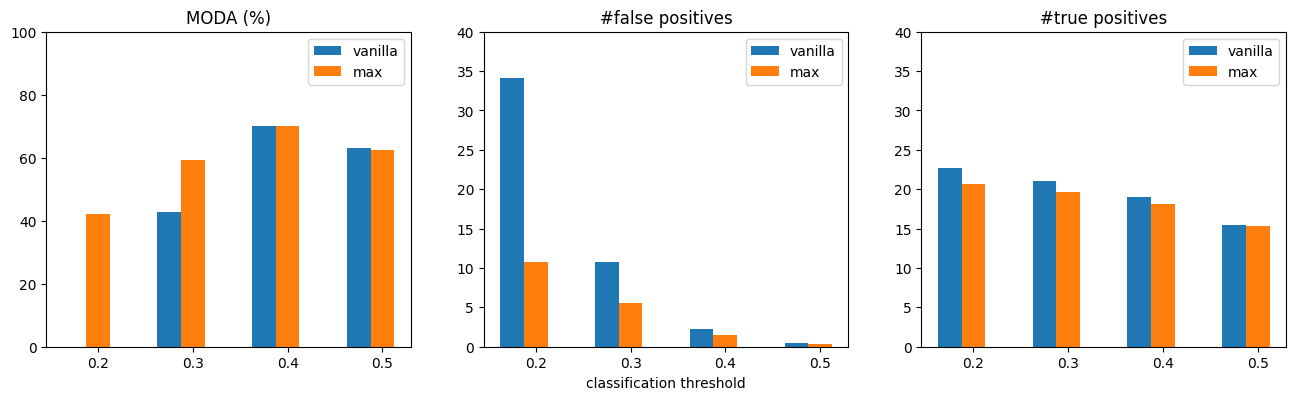

In [166]:
fig = plt.figure(figsize=(16,9))
subplt0 = fig.add_subplot(231, title="MODA (%)")
subplt1 = fig.add_subplot(232, title="#false positives")
subplt2 = fig.add_subplot(233, title="#true positives")
# subplt2 = fig.add_subplot(223, title="fp_max")
# subplt3 = fig.add_subplot(224, title="tp_max")

# subplt0.bar(["0.2", "0.3", "0.4"], fp_list)
# subplt1.bar(["0.2", "0.3", "0.4"], tp_list)
# subplt2.bar(["0.2", "0.3", "0.4"], fp_list_max)
# subplt3.bar(["0.2", "0.3", "0.4"], tp_list_max)

fp_dict = {"vanilla": fp_list, "max": fp_list_max}
tp_dict = {"vanilla": tp_list, "max": tp_list_max}
moda_dict = {"vanilla": moda_list, "max": moda_list_max}

x = np.arange(4)
labels=["0.2", "0.3", "0.4", "0.5"]
width = 0.25
for i, (k, v) in enumerate(fp_dict.items()):
    subplt1.bar(x + i*width, np.array(v)/40, width, label=k)

for i, (k, v) in enumerate(tp_dict.items()):
    subplt2.bar(x + i*width, np.array(v)/40, width, label=k)

for i, (k, v) in enumerate(moda_dict.items()):
    subplt0.bar(x + i*width, np.array(v), width, label=k)



subplt0.set_xticks(x+width, labels)
subplt1.set_xticks(x+width, labels)
subplt2.set_xticks(x+width, labels)
subplt0.legend()
subplt1.legend()
subplt2.legend()
subplt0.set_ylim(0, 100)
subplt1.set_ylim(0, 40)
subplt2.set_ylim(0, 40)
subplt1.set_xlabel("classification threshold")


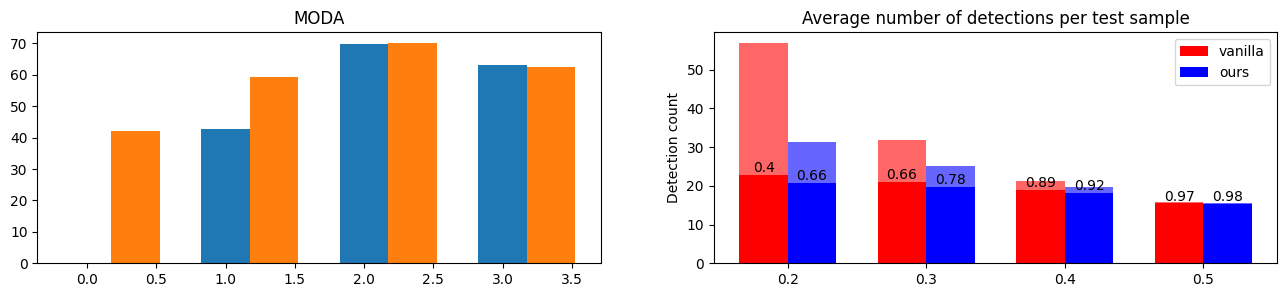

In [167]:
fig = plt.figure(figsize=(16,3))
# fig = plt.figure()
subplt0 = fig.add_subplot(121, title="MODA")
ax = fig.add_subplot(122, title="Average number of detections per test sample")



species = ('0.2', '0.3', '0.4', '0.5')
x_range = np.arange(len(species))
sex_counts = {
    'TP': np.array(tp_list) / 40,
    'FP': np.array(fp_list) / 40,
}
width = 0.35  # the width of the bars: can also be len(x) sequence


# fig, ax = plt.subplots()
bottom = np.zeros(4)

for sex, sex_count in sex_counts.items():
    if sex == "TP":
        p = ax.bar(x_range - width/2, sex_count, width, label="vanilla", bottom=bottom, color=(1.0,0,0))
        ax.bar_label(p, labels=np.round(sex_count / (sex_counts["TP"] + sex_counts["FP"]), 2), label_type='edge')
    else:
        p = ax.bar(x_range - width/2, sex_count, width, bottom=bottom, color=(1.0,0.,0.), alpha=0.6)

    bottom += sex_count

bottom = np.zeros(4)
sex_counts = {
    'TP': np.array(tp_list_max) / 40,
    'FP': np.array(fp_list_max) / 40,
}
for sex, sex_count in sex_counts.items():
    if sex == "TP":
        p = ax.bar(x_range + width/2, sex_count, width, label="ours", bottom=bottom, color=(0.,0.,1.0))
        ax.bar_label(p, labels=np.round(sex_count / (sex_counts["TP"] + sex_counts["FP"]), 2), label_type='edge')
    else:
        p = ax.bar(x_range + width/2, sex_count, width, bottom=bottom, color=(0.,0.,1.), alpha=0.6)

    bottom += sex_count

ax.set_title('Average number of detections per test sample')
ax.legend()
ax.set_ylabel("Detection count")
# ax.set_xlabel("Classification threshold")
ax.set_xticks(x_range, species)

moda_dict = {"vanilla": moda_list, "max": moda_list_max}
for i, (k, v) in enumerate(moda_dict.items()):
    subplt0.bar(x_range + i*width, np.array(v), width, label=k)


# plt.xticks(x_range, species)
# plt.xlabel("Classification threshold")
plt.show()


'/mnt/2024-09-30_15-06-08-691207/test_0/cls_thres=0.2, nms_thres=20.png'

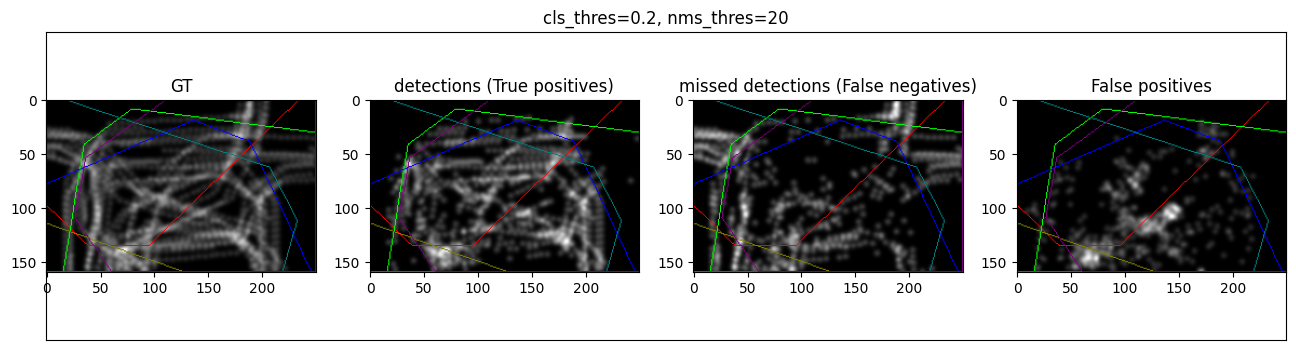

In [23]:
# plot for normal detections
map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot = get_detection_heatmaps(gtAllMatrix=gtAllMatrix,
                                                                                  detAllMatrix=detAllMatrix,
                                                                                  criterion=criterion,
                                                                                  test_loader=test_loader,
                                                                                  map_gt=map_gt,
                                                                                  dataset_name=dataset_name,
                                                                                  indexing=test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing)
# True positive heatmap
map_gt_img = display_cam_layout(map_gt_tot / np.max(map_gt_tot), view_indicator_list)
map_detected_img = display_cam_layout(map_detected_tot / np.max(map_detected_tot), view_indicator_list)
map_missed_tot_img = display_cam_layout(map_missed_tot / np.max(map_missed_tot), view_indicator_list)
map_fp_tot_img = display_cam_layout(map_fp_tot / np.max(map_fp_tot), view_indicator_list)

fig = plt.figure(figsize=(16,4))
plt.title(f"cls_thres={cls_thres}, nms_thres={nms_thres}")
plt.xticks([])
plt.yticks([])
subplt0 = fig.add_subplot(141, title="GT")
subplt1 = fig.add_subplot(142, title="detections (True positives)")
subplt2 = fig.add_subplot(143, title="missed detections (False negatives)")                
subplt3 = fig.add_subplot(144, title="False positives")                
subplt0.imshow(map_gt_img)
subplt1.imshow(map_detected_img)
subplt2.imshow(map_missed_tot_img)
subplt3.imshow(map_fp_tot_img)

save_path = os.path.join(os.path.dirname(res_path), f"cls_thres={cls_thres}, nms_thres={nms_thres}.png")
plt.savefig(save_path)
save_path

'/mnt/2024-09-30_15-06-08-691207/test_0/cls_thres=0.2, k_size=25.png'

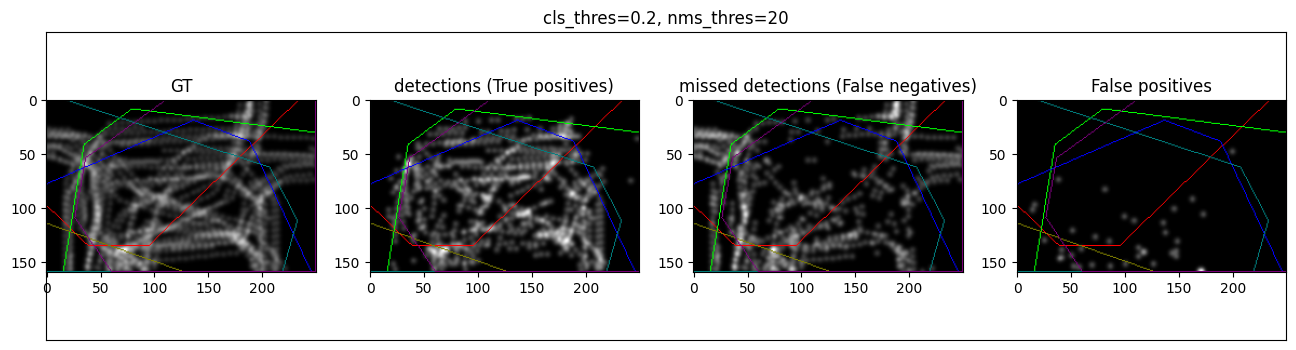

In [24]:
# plot for max detections
map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot = get_detection_heatmaps(gtAllMatrix=gtAllMatrix,
                                                                                  detAllMatrix=detAllMatrix_max,
                                                                                  criterion=criterion,
                                                                                  test_loader=test_loader,
                                                                                  map_gt=map_gt,
                                                                                  dataset_name=dataset_name,
                                                                                  indexing=test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing)
# True positive heatmap
map_gt_img = display_cam_layout(map_gt_tot / np.max(map_gt_tot), view_indicator_list)
map_detected_img = display_cam_layout(map_detected_tot / np.max(map_detected_tot), view_indicator_list)
map_missed_tot_img = display_cam_layout(map_missed_tot / np.max(map_missed_tot), view_indicator_list)
map_fp_tot_img = display_cam_layout(map_fp_tot / np.max(map_fp_tot), view_indicator_list)

fig = plt.figure(figsize=(16,4))
plt.title(f"cls_thres={cls_thres}, nms_thres={nms_thres}")
plt.xticks([])
plt.yticks([])
subplt0 = fig.add_subplot(141, title="GT")
subplt1 = fig.add_subplot(142, title="detections (True positives)")
subplt2 = fig.add_subplot(143, title="missed detections (False negatives)")                
subplt3 = fig.add_subplot(144, title="False positives")                
subplt0.imshow(map_gt_img)
subplt1.imshow(map_detected_img)
subplt2.imshow(map_missed_tot_img)
subplt3.imshow(map_fp_tot_img)

save_path = os.path.join(os.path.dirname(res_path), f"cls_thres={cls_thres}, k_size={k_size}.png")
plt.savefig(save_path)
save_path

# compare modp between different nms methods (only count modp on the TP detections that are common between the two methods)

83.1175360770701

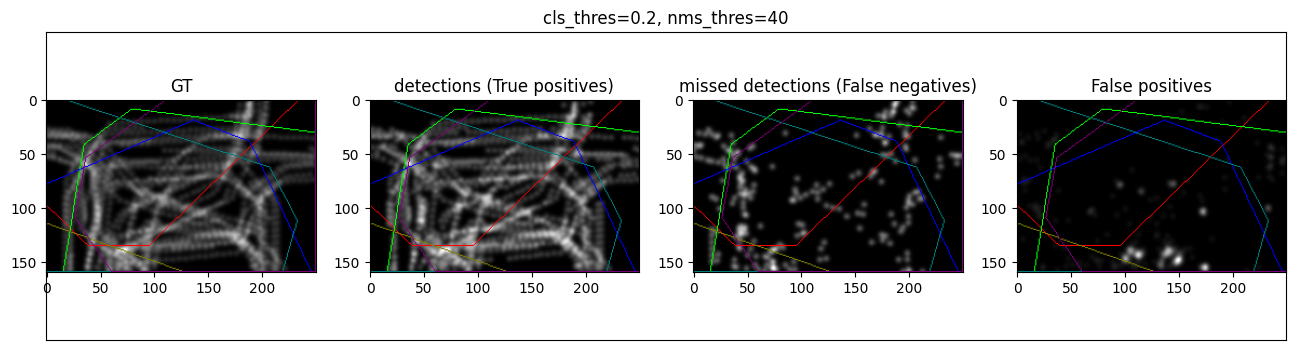

In [50]:
modp_list, map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot = get_modp_and_common_detection_heatmaps(
    gtAllMatrix,
    detAllMatrix,
    detAllMatrix_max,
    criterion,
    test_loader,
    map_gt,
    dataset_name
)
# True positive heatmap
map_gt_img = display_cam_layout(map_gt_tot / np.max(map_gt_tot), view_indicator_list)
map_detected_img = display_cam_layout(map_detected_tot / np.max(map_detected_tot), view_indicator_list)
map_missed_tot_img = display_cam_layout(map_missed_tot / np.max(map_missed_tot), view_indicator_list)
map_fp_tot_img = display_cam_layout(map_fp_tot / np.max(map_fp_tot), view_indicator_list)

fig = plt.figure(figsize=(16,4))
plt.title(f"cls_thres={cls_thres}, nms_thres={nms_thres}")
plt.xticks([])
plt.yticks([])
subplt0 = fig.add_subplot(141, title="GT")
subplt1 = fig.add_subplot(142, title="detections (True positives)")
subplt2 = fig.add_subplot(143, title="missed detections (False negatives)")                
subplt3 = fig.add_subplot(144, title="False positives")                
subplt0.imshow(map_gt_img)
subplt1.imshow(map_detected_img)
subplt2.imshow(map_missed_tot_img)
subplt3.imshow(map_fp_tot_img)

np.mean(modp_list)

83.29272204292133

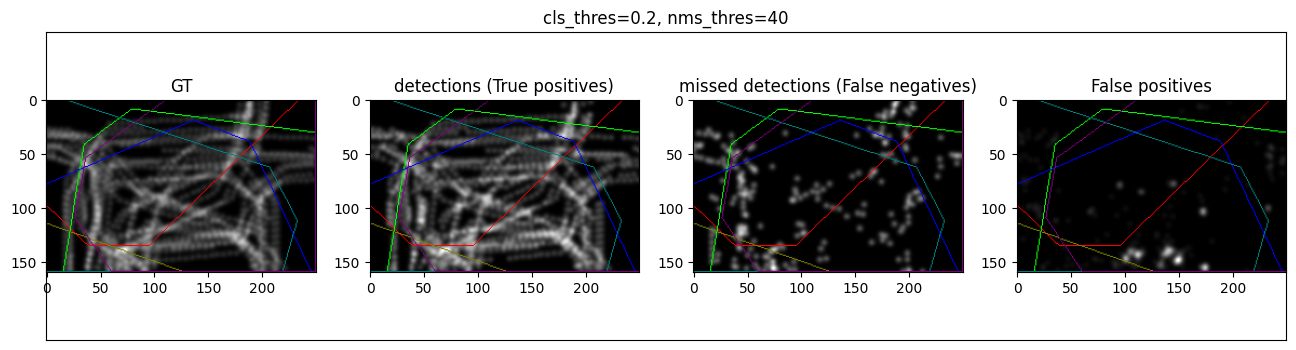

In [51]:
modp_list, map_gt_tot, map_detected_tot, map_missed_tot, map_fp_tot = get_modp_and_common_detection_heatmaps(
    gtAllMatrix,
    detAllMatrix_max,
    detAllMatrix,
    criterion,
    test_loader,
    map_gt,
    dataset_name
)
# True positive heatmap
map_gt_img = display_cam_layout(map_gt_tot / np.max(map_gt_tot), view_indicator_list)
map_detected_img = display_cam_layout(map_detected_tot / np.max(map_detected_tot), view_indicator_list)
map_missed_tot_img = display_cam_layout(map_missed_tot / np.max(map_missed_tot), view_indicator_list)
map_fp_tot_img = display_cam_layout(map_fp_tot / np.max(map_fp_tot), view_indicator_list)

fig = plt.figure(figsize=(16,4))
plt.title(f"cls_thres={cls_thres}, nms_thres={nms_thres}")
plt.xticks([])
plt.yticks([])
subplt0 = fig.add_subplot(141, title="GT")
subplt1 = fig.add_subplot(142, title="detections (True positives)")
subplt2 = fig.add_subplot(143, title="missed detections (False negatives)")                
subplt3 = fig.add_subplot(144, title="False positives")                
subplt0.imshow(map_gt_img)
subplt1.imshow(map_detected_img)
subplt2.imshow(map_missed_tot_img)
subplt3.imshow(map_fp_tot_img)

np.mean(modp_list)

# visualize a single example

In [43]:
(data, map_gt, imgs_gt, frame, proj_mats, _, _, _, _, dataset_name) = next(iterator)
with torch.no_grad():
    config_dict = test_loader.dataset.dicts[dataset_name[0]]
    map_res, imgs_res, (world_features, img_features, view_indicator_list) = model(data, proj_mats, config_dict)

map_res_cpu = map_res.detach().cpu().squeeze()

Text(0.5, 1.0, 'pseudo-label\ncls_thres=0.8, nms_thres=5')

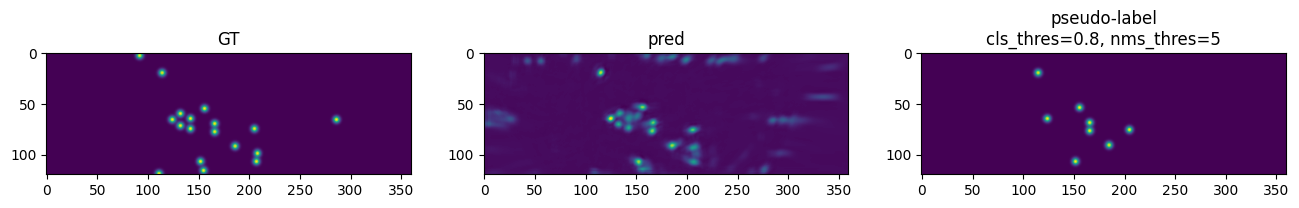

In [54]:
pseudo_label_th = 0.8
nms_thres = 5

gt_pos = (map_gt.detach().cpu().squeeze() > 0).nonzero().float()
scores = map_res_cpu[map_res_cpu > pseudo_label_th]
positions = (map_res_cpu > pseudo_label_th).nonzero().float()

if not torch.numel(positions) == 0:
    ids, count = nms(positions.float(), scores, nms_thres, np.inf)
    positions = positions[ids[:count], :]
    scores = scores[ids[:count]]
map_pseudo_label = torch.zeros_like(map_res)
for pos in positions:
    map_pseudo_label[:,:,int(pos[0].item()), int(pos[1].item())] = 1
                    

pseudo_label_viz = criterion._traget_transform(map_res, map_pseudo_label, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
map_gt_viz = criterion._traget_transform(map_gt, map_gt, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
# plt.imshow(pseudo_label_viz)
# plt.title(f"cls_thres={pseudo_label_th}, nms_thres={nms_thres}")
fig = plt.figure(figsize=(16,9))
subplt0 = fig.add_subplot(131, title="GT")
subplt1 = fig.add_subplot(132, title="pred")
subplt2 = fig.add_subplot(133, title="pseudo label")                
subplt0.imshow(map_gt_viz)
subplt1.imshow(map_res_cpu)
subplt2.imshow(pseudo_label_viz)
plt.title(f"pseudo-label\ncls_thres={pseudo_label_th}, nms_thres={nms_thres}")


Text(0.5, 1.0, 'pseudo-label\ncls_thres=0.8, nms_thres=5')

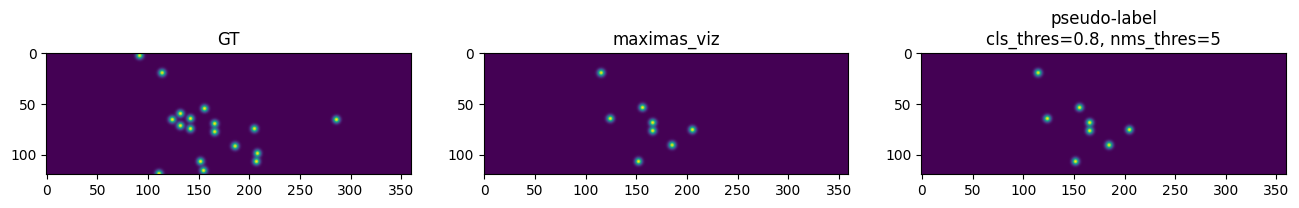

In [55]:
pseudo_label_th = 0.8
k_size = 7 # only wokr with odd numbers
pad_size = int(k_size/2)


temp = torch.max_pool2d(map_res_cpu.unsqueeze(0), k_size, stride=1,padding=(pad_size, pad_size))
# temp = torch.max_pool2d(map_res_cpu.unsqueeze(0), max_pool_kernel)
# upsampled_max = torch.nn.functional.interpolate(temp.unsqueeze(0), map_res_cpu.shape, mode="nearest")
maximas = temp.squeeze() == map_res_cpu
maximas = maximas & (map_res_cpu > pseudo_label_th)
maximas = maximas.unsqueeze(0).unsqueeze(0).float()
maximas_viz = criterion._traget_transform(maximas, maximas, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
fig = plt.figure(figsize=(16,9))
subplt0 = fig.add_subplot(131, title="GT")
subplt1 = fig.add_subplot(132, title="maximas_viz")
subplt2 = fig.add_subplot(133, title="pseudo label")                
subplt0.imshow(map_gt_viz)
subplt1.imshow(maximas_viz)
subplt2.imshow(pseudo_label_viz)
plt.title(f"pseudo-label\ncls_thres={pseudo_label_th}, nms_thres={nms_thres}")


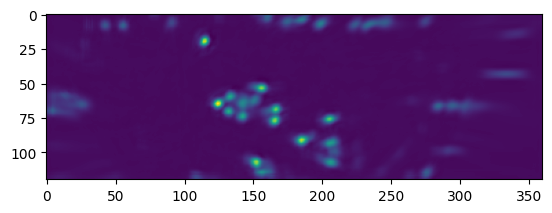

In [57]:
plt.imshow(map_res_cpu)

positions_maximas = (maximas.squeeze() > 0).nonzero().float()
positions_gt = (map_gt.squeeze() > 0).nonzero().float()

# for pos in positions_gt:
#     plt.plot(pos[1], pos[0], 'co')
    
# for pos in positions:
#     plt.plot(pos[1], pos[0], 'r*')

# for pos in positions_maximas:
#     plt.plot(pos[1], pos[0], 'gx')



In [76]:
# pseudo_label_th = 0.2

img_viz_list = []
for pseudo_label_th in [0.2, 0.3, 0.4]:

    nms_thres = 5

    gt_pos = (map_gt.detach().cpu().squeeze() > 0).nonzero().float()
    scores = map_res_cpu[map_res_cpu > pseudo_label_th]
    positions = (map_res_cpu > pseudo_label_th).nonzero().float()

    if not torch.numel(positions) == 0:
        ids, count = nms(positions.float(), scores, nms_thres, np.inf)
        positions = positions[ids[:count], :]
        scores = scores[ids[:count]]
    map_pseudo_label = torch.zeros_like(map_res)
    for pos in positions:
        map_pseudo_label[:,:,int(pos[0].item()), int(pos[1].item())] = 1
                        

    pseudo_label_viz = criterion._traget_transform(map_res, map_pseudo_label, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    map_gt_viz = criterion._traget_transform(map_gt, map_gt, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    # plt.imshow(pseudo_label_viz)
    # plt.title(f"cls_thres={pseudo_label_th}, nms_thres={nms_thres}")
    # fig = plt.figure(figsize=(16,9))
    # subplt0 = fig.add_subplot(131, title="GT")
    # subplt1 = fig.add_subplot(132, title="pred")
    # subplt2 = fig.add_subplot(133, title="pseudo label")                
    # subplt0.imshow(map_gt_viz)
    # subplt1.imshow(map_res_cpu)
    # subplt2.imshow(pseudo_label_viz)
    # plt.title(f"pseudo-label\ncls_thres={pseudo_label_th}, nms_thres={nms_thres}")


    # pseudo_label_th = 0.20
    k_size = 7 # only wokr with odd numbers
    pad_size = int(k_size/2)


    temp = torch.max_pool2d(map_res_cpu.unsqueeze(0), k_size, stride=1,padding=(pad_size, pad_size))
    # temp = torch.max_pool2d(map_res_cpu.unsqueeze(0), max_pool_kernel)
    # upsampled_max = torch.nn.functional.interpolate(temp.unsqueeze(0), map_res_cpu.shape, mode="nearest")
    maximas = temp.squeeze() == map_res_cpu
    maximas = maximas & (map_res_cpu > pseudo_label_th)
    maximas = maximas.unsqueeze(0).unsqueeze(0).float()
    maximas_viz = criterion._traget_transform(maximas, maximas, test_loader.dataset.dicts[dataset_name[0]]['base'].map_kernel).cpu().detach().numpy().squeeze()
    # fig = plt.figure(figsize=(16,9))
    # subplt0 = fig.add_subplot(131, title="GT")
    # subplt1 = fig.add_subplot(132, title="maximas_viz")
    # subplt2 = fig.add_subplot(133, title="pseudo label")                
    # subplt0.imshow(map_gt_viz)
    # subplt1.imshow(maximas_viz)
    # subplt2.imshow(pseudo_label_viz)
    # plt.title(f"pseudo-label\ncls_thres={pseudo_label_th}, nms_thres={nms_thres}")

    img_viz_list.append((map_res_cpu, maximas, map_gt, positions))

fig = plt.figure(figsize=(16,9))
# plt.rcParams['text.usetex'] = True
subplt0 = fig.add_subplot(131, title="$\tau=0.2$")
subplt1 = fig.add_subplot(132, title="0.3")
subplt2 = fig.add_subplot(133, title="0.4")  
for (map_res_cpu, maximas, map_gt, positions), subplot in zip(img_viz_list, [subplt0, subplt1, subplt2]):
    subplot.imshow(map_res_cpu)

    positions_maximas = (maximas.squeeze() > 0).nonzero().float()
    positions_gt = (map_gt.squeeze() > 0).nonzero().float()

    for pos in positions_gt:
        subplot.plot(pos[1], pos[0], 'co')
        
    for pos in positions:
        subplot.plot(pos[1], pos[0], 'r*')

    for pos in positions_maximas:
        subplot.plot(pos[1], pos[0], 'gx')

RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1600x900 with 3 Axes>

# analyze non-max and max detections
Basically, the vanilla post-processing produces detections of two kinds: (1) detections that are local maximas, and (2) detections that are not local maximas.

By analyzing the characteristics of these two different kinds of detections, we can motivate why it may be beneficial to only focus on the local maxima ones.

The analysis below shows that the precision/accuracy (i.e. TP/(FP+TP)) is much higher for detections of class (1).
This is hardly surprising, but is a good indication on using this criterio for finding reliable detections.

However, one may still wonder if the requirement of local maxima is too strict, i.e., recall may become too small? How do we motivate this?

In [271]:

def pos_in_tensor(pos, tensor):
    # pos has shape 2,
    # tensor has shape n x 2
    pos_repeated = pos.repeat((tensor.shape[0], 1))
    check = pos_repeated == tensor
    checked_sum = torch.sum(check, dim=1) > 1
    pos_in_tensor = torch.sum(checked_sum) > 0

    return pos_in_tensor.item()


In [370]:
tp_list = []
fp_list = []
moda_list = []
tp_list_max = []
fp_list_max = []
moda_list_max = []

In [371]:

# # gmvd scene1 conf 2 -> multiviewx 
# # res_path = os.path.join(os.path.dirname(args.resume_model), "test_12", "all_res.txt")

# # gmvd scene1 conf 1 -> multiviewx
# # wildtrack -> multiviewx
# # wildtrack -> multiviewx UDA
# res_path = os.path.join(os.path.dirname(args.resume_model), "test_0", "all_res.txt")

# # multiviewx->wildtrack
# # res_path = os.path.join(os.path.dirname(args.resume_model), "test_5", "all_res.txt")

# # wildtrack -> multiviewx new baseline
# args.resume_model = "/mnt/2024-09-30_15-06-08-691207/MultiviewDetector.pth"
# # test on source data
# # res_path = os.path.join(os.path.dirname(args.resume_model), "test_1", "all_res.txt")


print("res_path: ", res_path)
gt_path = test_loader.dataset.dicts[dataset_name[0]]["base"].gt_fpath
print("gt_path: ", gt_path)

cls_thres = 0.2
nms_thres = 20

# k_size = 7 # only wokr with odd numbers
k_size = 25 # only wokr with odd numbers
pad_size = int(k_size/2)

all_res_list_thres = np.loadtxt(res_path)
all_res_list_thres = torch.tensor(all_res_list_thres)
all_res_list_thres = all_res_list_thres[all_res_list_thres[:, -1] > cls_thres]

res_list = []
res_list_max = []
all_scores = []
all_scores_max = []
for frame in np.unique(all_res_list_thres[:, 0]):
    res = all_res_list_thres[all_res_list_thres[:, 0] == frame, :]
    positions, scores = res[:, 1:3], res[:, 3]

    # standard nms results
    ids, count = nms(positions, scores, nms_thres, np.inf)
    positions_vanilla = positions[ids[:count], :]
    scores_vanilla = scores[ids[:count]]

    # res_list.append(torch.cat([torch.ones([count, 1]) * frame, positions[ids[:count], :]], dim=1))

    # maxima results
    decoded_res = torch.zeros(tuple([x for x in test_loader.dataset.dicts[dataset_name[0]]['base'].base.world_grid_shape])).cuda()
    for pos, s in zip(positions, scores):
        if test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing == "ij":
            decoded_res[int(pos[0].item()), int(pos[1].item())] = s
        else:
            decoded_res[int(pos[1].item()), int(pos[0].item())] = s
    temp = torch.max_pool2d(decoded_res.unsqueeze(0), k_size, stride=1,padding=(pad_size, pad_size))
    maximas = temp.squeeze() == decoded_res
    maximas = maximas & (decoded_res >= cls_thres)
    scores = decoded_res[maximas].cpu()
    maximas = maximas.float()
    positions = (maximas > 0).nonzero().float().cpu()
    if not test_loader.dataset.dicts[dataset_name[0]]['base'].base.indexing == "ij":
        positions = positions[:, [1, 0]]
    positions_max = positions

    max_positions = []
    non_max_positions = []
    for pos, s in zip(positions_vanilla, scores_vanilla):
        if pos_in_tensor(pos, positions_max):
            max_positions.append(pos.unsqueeze(0))
            all_scores_max.append(s.item())
        else:
            non_max_positions.append(pos.unsqueeze(0))
            all_scores.append(s.item())

    if max_positions:
        max_positions = torch.concat(max_positions, dim=0)
        res_list_max.append(torch.cat([torch.ones([max_positions.shape[0], 1]) * frame, max_positions], dim=1))

    if non_max_positions:
        non_max_positions = torch.concat(non_max_positions, dim=0)
        res_list.append(torch.cat([torch.ones([non_max_positions.shape[0], 1]) * frame, non_max_positions], dim=1))

all_scores = torch.tensor(all_scores)
all_scores_max = torch.tensor(all_scores_max)
res_list = torch.cat(res_list, dim=0).numpy() if res_list else np.empty([0, 3])
res_list_max = torch.cat(res_list_max, dim=0).numpy() if res_list_max else np.empty([0, 3])


In [318]:
gtAllMatrix, detAllMatrix = load_res(res_list, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix)
tp = gtAllMatrix.shape[0]*recall/100
fp = detAllMatrix.shape[0] - detAllMatrix.shape[0]*precision/100
tp_list.append(tp)
fp_list.append(fp)
moda_list.append(MODA)
recall, precision, MODA, MODP

(42.016806722689076, 39.02439024390244, 0, 26.559758576388827)

In [319]:
gtAllMatrix, detAllMatrix_max = load_res(res_list_max, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix_max)
tp = gtAllMatrix.shape[0]*recall/100
fp = detAllMatrix_max.shape[0] - detAllMatrix_max.shape[0]*precision/100
tp_list_max.append(tp)
fp_list_max.append(fp)
moda_list_max.append(MODA)
recall, precision, MODA, MODP

(86.5546218487395, 65.97277822257807, 41.91176470588235, 72.47199796326433)

In [372]:
acc_list_max = []
acc_list_max_count = []

for th in [0.2, 0.3]:
    temp_preds = res_list_max[(all_scores_max > th) & (all_scores_max < th + 0.1)]
    gtAllMatrix, detAllMatrix_max = load_res(temp_preds, np.loadtxt(gt_path))
    recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix_max)
    acc_list_max.append(precision)
    acc_list_max_count.append(temp_preds.shape[0])

temp_preds = res_list_max[all_scores_max > 0.4]
gtAllMatrix, detAllMatrix_max = load_res(temp_preds, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix_max)
acc_list_max.append(precision)
acc_list_max_count.append(temp_preds.shape[0])

acc_list = []
acc_list_count = []

for th in [0.2, 0.3]:
    temp_preds = res_list[(all_scores > th) & (all_scores < th + 0.1)]
    gtAllMatrix, detAllMatrix = load_res(temp_preds, np.loadtxt(gt_path))
    recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix)
    acc_list.append(precision)
    acc_list_count.append(temp_preds.shape[0])

temp_preds = res_list[all_scores > 0.4]
gtAllMatrix, detAllMatrix = load_res(temp_preds, np.loadtxt(gt_path))
recall, precision, MODA, MODP = CLEAR_MOD_HUN(gtAllMatrix, detAllMatrix)
acc_list.append(precision)
acc_list_count.append(temp_preds.shape[0])


In [373]:
acc_list

[36.87002652519894, 40.77669902912621, 73.84615384615385]

In [374]:

[x / 40 for x in acc_list_count]

[18.85, 5.15, 1.625]

In [375]:
acc_list_max

[16.93548387096774, 26.38888888888889, 92.35668789808918]

In [376]:
[x / 40 for x in acc_list_max_count]

[6.2, 5.4, 19.625]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:

y = np.array([0.0, 0.01, 0.03, 0.05, 0.15, 0.33, 0.45, 0.75, 0.8, 0.73, 0.65, 0.5,0.38, 0.35, 0.2, 0.15, 0.09, 0.03])
x = np.arange(len(y))

Text(0, 0.5, 'Predicted score')

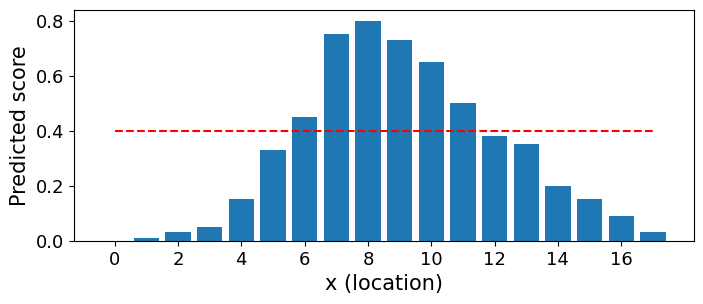

In [52]:
plt.figure(figsize=(8,3))
plt.bar(x, y)
plt.xticks(np.arange(0, 17, 2), fontsize=13)
plt.yticks(fontsize=13)
plt.hlines(0.4, np.min(x), np.max(x), linestyles="dashed", colors=(1.0, 0., 0.))
# plt.hlines(0.3, np.min(x), np.max(x), linestyles="dashed", colors=(1.0, 0., 0.))
plt.xlabel("x (location)", fontsize=15)
plt.ylabel("Predicted score", fontsize=15)
# plt.xticks(fontsize=15)

([<matplotlib.axis.XTick at 0x7fee3dbfd100>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

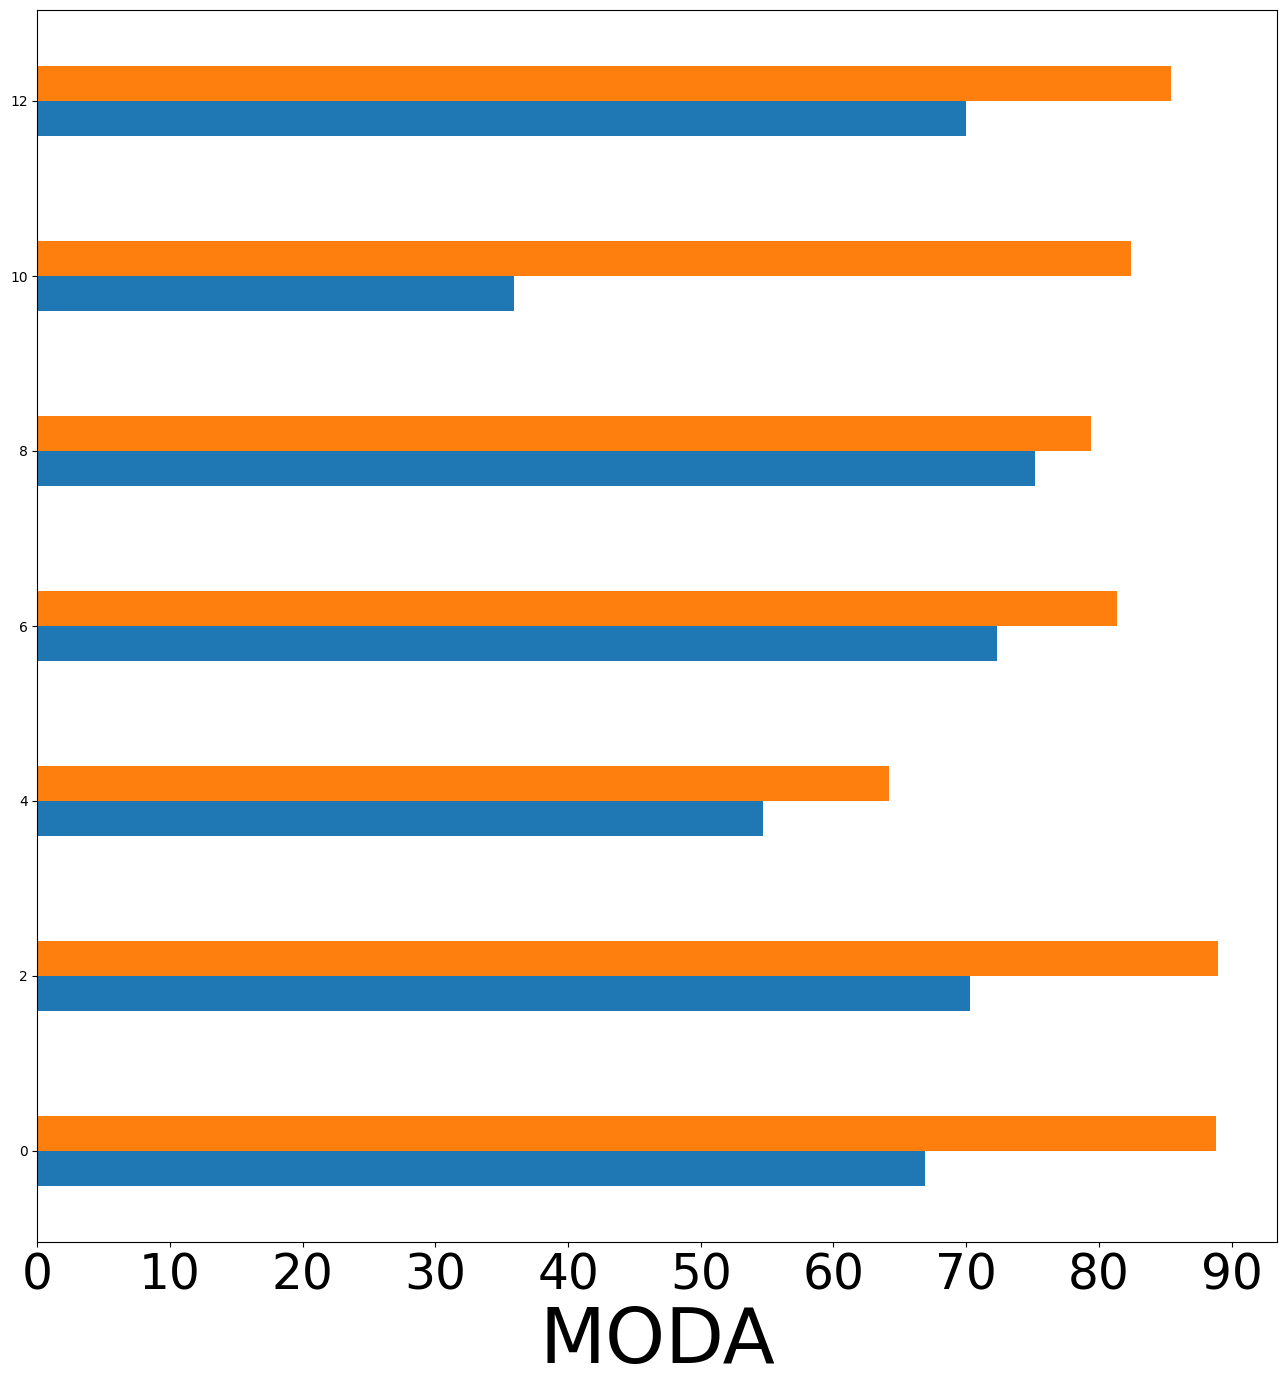

In [39]:

plt.figure(figsize=(16,16))
baseline = [70, 35.9, 75.2, 72.3, 54.7, 70.3, 66.9]
uda = [85.4, 82.4, 79.4, 81.4, 64.2, 89.0, 88.8]
baseline.reverse()
uda.reverse()
baseline = np.array(baseline)
uda = np.array(uda)
x = 2*np.arange(len(uda))
width = 0.4
plt.barh(x - width / 2, baseline, height=width, label="Baseline")
plt.barh(x + width / 2, uda, height=width, label="UDA")
# plt.barh(x + width / 2, uda, width=width)
# plt.legend()
benchmarks = [r"\sum", "Wildtrack->MultiviewX", "Wildtrack->MultiviewX", "Wildtrack->MultiviewX" ,"Wildtrack->MultiviewX" ,"Wildtrack->MultiviewX" ,"Wildtrack->MultiviewX"]
# plt.xticks(ticks=x, labels=benchmarks, rotation='vertical')
plt.xlabel("MODA", fontsize=55)
plt.xticks(np.arange(0, 100, 10), fontsize=35)
# plt.axis("off")

In [6]:
len(uda)

7

# visualize grid

In [100]:
denormalize = img_color_denormalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

def get_start_end_line(line1, proj_mats):
    grid = line1.reshape((2, -1))
    grid_homo = torch.ones((3, grid.shape[1]))
    grid_homo[0:2, :] = grid
    grid_homo = grid_homo.unsqueeze(0)
    print(torch.linalg.inv(proj_mats[0]).float().to('cuda:0').shape)
    grid_persp = torch.bmm(torch.linalg.inv(proj_mats[0]).float().to('cuda:0'), grid_homo.to('cuda:0')).cpu().numpy().squeeze()
    z = grid_persp[2,:].copy()

    grid_persp = grid_persp / z# *720/270

    # Image.fromarray((img * 255).astype('uint8'))
    # img = np.array(img)
    # for p in grid_persp.transpose():
    #     img = cv2.circle(img, (int(p[0]), int(p[1])), 1, (0,0,255), -1)
    grid_persp = grid_persp.reshape(3, len(z))

    start=None
    for i in range(len(z)):
        if z[i] <= 0:
            continue
        else:
            if start is None:
                start =  [int(x) for x in (grid_persp[0,i],grid_persp[1,i])]
            else:
                end = [int(x) for x in (grid_persp[0,i],grid_persp[1,i])]

    return start, end


In [101]:
imgs = data[0]
cam=0
img = denormalize(imgs[cam])[0]
img = (img.cpu().numpy().transpose([1, 2, 0]) * 255).astype('uint8')
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

bev_w, bev_h = test_loader.dataset.dicts[dataset_name[0]]["base"].reducedgrid_shape

# x = torch.linspace(0, bev_h-1, bev_h)
x = torch.linspace(0, bev_h-1, int(bev_h))
# y = torch.linspace(0, bev_w-1, bev_w)
y = torch.linspace(0, bev_w-1, int(bev_w))
mesh = torch.meshgrid([x,y], indexing="xy")
grid = torch.concat([mesh[0].unsqueeze(0), mesh[1].unsqueeze(0)])

line1 = grid[:,:,-1]
start, end = get_start_end_line(line1, projm_img2bevred)
img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

line1 = grid[:,:,0]
start, end = get_start_end_line(line1, projm_img2bevred)
img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

line1 = grid[:,0,:]
start, end = get_start_end_line(line1, projm_img2bevred)
img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

line1 = grid[:,-1,:]
start, end = get_start_end_line(line1, projm_img2bevred)
img = cv2.line(img, tuple(start), tuple(end),(255,0,0))


# grid = line1.reshape((2, -1))
# grid_homo = torch.ones((3, grid.shape[1]))
# grid_homo[0:2, :] = grid
# grid_homo = grid_homo.unsqueeze(0)
# grid_persp = torch.bmm(torch.linalg.inv(proj_mats[0]).float().to('cuda:0'), grid_homo.to('cuda:0')).cpu().numpy().squeeze()
# z = grid_persp[2,:].copy()

# grid_persp = grid_persp / z *720/270

# Image.fromarray((img * 255).astype('uint8'))
# img = np.array(img)
# for p in grid_persp.transpose():
#     img = cv2.circle(img, (int(p[0]), int(p[1])), 1, (0,0,255), -1)
# grid_persp = grid_persp.reshape(3, len(z))

# start=None
# for i in range(len(z)):
#     if z[i] <= 0:
#         continue
#     else:
#         if start is None:
#             start =  [int(x) for x in (grid_persp[0,i],grid_persp[1,i])]
#         else:
#             end = [int(x) for x in (grid_persp[0,i],grid_persp[1,i])]



# # # start = [min(max(int(x),0),img.shape[1]) for x in (grid_persp[0,0,0],grid_persp[1,0,0])]
# # # end = [min(max(int(x),0),img.shape[0]) for x in (grid_persp[0,0,-1],grid_persp[1,0,-1])]
# start = [int(x) for x in (grid_persp[0,0,0],grid_persp[1,0,0])]
# end = [int(x) for x in (grid_persp[0,0,-1],grid_persp[1,0,-1])]
# img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

# start = [int(x) for x in (grid_persp[0,0,0],grid_persp[1,0,0])]
# end = [int(x) for x in (grid_persp[0,-1,0],grid_persp[1,-1,0])]
# img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

# # start = [min(max(int(x),0),img.shape[0]) for x in (grid_persp[0,-1,0],grid_persp[1,-1,0])]
# # end = [min(max(int(x),0),img.shape[1]) for x in (grid_persp[0,-1,-1],grid_persp[1,-1,-1])]
# start = [int(x) for x in (grid_persp[0,-1,0],grid_persp[1,-1,0])]
# end = [int(x) for x in (grid_persp[0,-1,-1],grid_persp[1,-1,-1])]
# img = cv2.line(img, tuple(start), tuple(end),(255,0,0))

# # start = [int(x) for x in (grid_persp[0,-1,-1],grid_persp[1,-1,-1])]
# # end = [int(x) for x in (grid_persp[0,0,-1],grid_persp[1,0,-1])]
# img = cv2.line(img, tuple(start), tuple(end),(255,0,0))




# img = img.transpose((2,1,0))

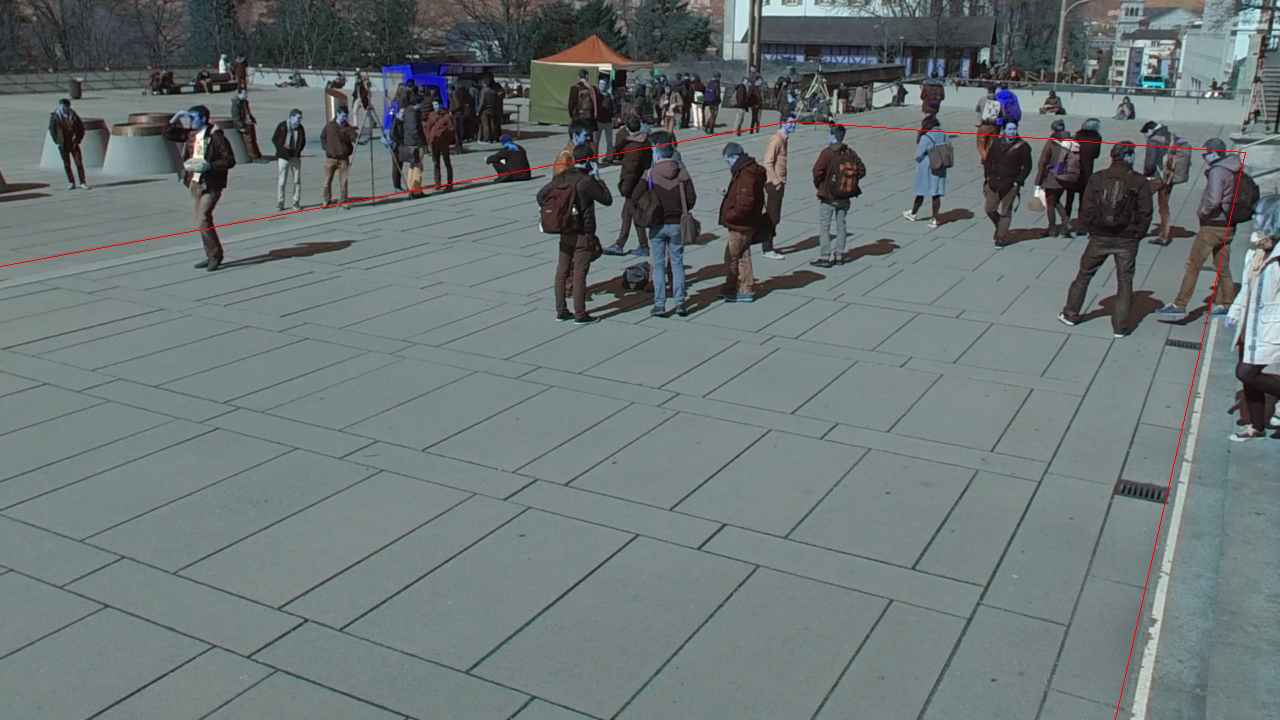

In [99]:
Image.fromarray(img)

In [88]:
end

[1245, 152]

In [103]:
torch.linalg.inv(proj_mats[0]).float().to('cuda:0').shape

torch.Size([1, 3, 3])

In [76]:
grid[:,0,:]

tensor([[  0.0000,   4.0337,   8.0674,  12.1011,  16.1348,  20.1685,  24.2022,
          28.2360,  32.2697,  36.3034,  40.3371,  44.3708,  48.4045,  52.4382,
          56.4719,  60.5056,  64.5393,  68.5730,  72.6067,  76.6405,  80.6742,
          84.7079,  88.7416,  92.7753,  96.8090, 100.8427, 104.8764, 108.9101,
         112.9438, 116.9775, 121.0112, 125.0450, 129.0787, 133.1124, 137.1461,
         141.1798, 145.2135, 149.2472, 153.2809, 157.3146, 161.3483, 165.3820,
         169.4157, 173.4494, 177.4832, 181.5168, 185.5506, 189.5843, 193.6180,
         197.6517, 201.6854, 205.7191, 209.7528, 213.7865, 217.8202, 221.8539,
         225.8876, 229.9213, 233.9550, 237.9888, 242.0225, 246.0562, 250.0899,
         254.1236, 258.1573, 262.1910, 266.2247, 270.2584, 274.2921, 278.3258,
         282.3596, 286.3932, 290.4270, 294.4607, 298.4944, 302.5281, 306.5618,
         310.5955, 314.6292, 318.6629, 322.6966, 326.7303, 330.7640, 334.7978,
         338.8315, 342.8652, 346.8989, 350.9326, 354

In [68]:
grid_persp[:,-1,0]

array([ 1677.3081   , -1733.3225   ,     2.6666667], dtype=float32)

In [104]:
img.shape

(720, 1280, 3)